In [2]:
import openai
import pandas as pd
import numpy as np
import tiktoken
from openai.embeddings_utils import get_embedding
import matplotlib.pyplot as plt

openai.api_key = 'REDACTED'  # stripped: hardcoded key removed


In [4]:
# embedding model parameters
set_1_raw = pd.read_csv('../../data/uw71_set1_redo_raw.csv') 
embedding_model = "text-embedding-ada-002"
embedding_encoding = "cl100k_base"  # this the encoding for text-embedding-ada-002
max_tokens = 8000  # the maximum for text-embedding-ada-002 is 8191

/var/folders/62/ybvc3cw53hj40799y980__gr0000gn/T/ipykernel_1525/1674446468.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  set_1_raw = pd.read_csv('../../data/uw71_set1_redo_raw.csv')


In [5]:
all_concepts = set_1_raw.prompt.unique()

In [6]:

encoding = tiktoken.get_encoding(embedding_encoding)

In [13]:
embeddings = [get_embedding(x, engine=embedding_model) for x in all_concepts]
embeddings = np.array(embeddings)
gpt3_embeddings = pd.DataFrame(embeddings)
gpt3_embeddings['concept'] = all_concepts

In [47]:
gpt3_embeddings.to_csv('../../data/gpt3embeddings.csv')

In [36]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca.fit(embeddings)
t_pca = pca.transform(embeddings)



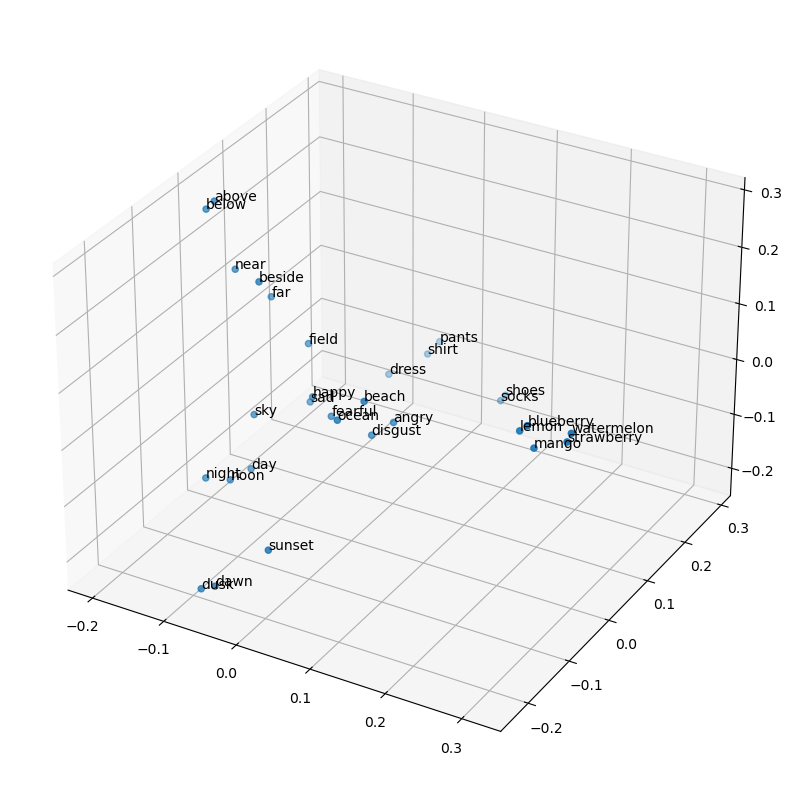

In [42]:
### make a 3d plot of t_pca
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(t_pca[:,0],t_pca[:,1],t_pca[:,2])
for i, txt in enumerate(all_concepts):
    ax.text(t_pca[i,0], t_pca[i,1], t_pca[i,2], txt)
plt.show()


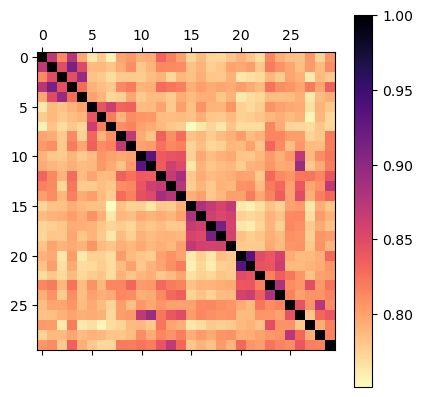

In [46]:
### createa a distance matrix for the embeddings
from sklearn.metrics.pairwise import euclidean_distances,cosine_similarity
dist = cosine_similarity(embeddings, embeddings)
dist = pd.DataFrame(dist)
dist.columns = all_concepts
dist.index = all_concepts
##now plot it

plt.matshow(dist, cmap='magma_r')
plt.colorbar()